# **Módulo 02 - Análise de dados de mercado com Python**

## **1. Coleta e limpeza de dados de mercado: IPOs**

Nesta seção, utilizamos dados de IPOs obtidos de uma tabela pública para
praticar a coleta, concatenação, limpeza e transformação de dados financeiros.
O objetivo é converter dados originalmente textuais e incompletos em um
DataFrame adequado para análise.

> Ideia central: dados financeiros reais chegam sujos, incompletos e distribuídos em fontes diferentes.


- **IPO (Initial Public Offering, ou oferta pública inicial) é o momento em que uma empresa de capital fechado vende suas ações ao público pela primeira vez e passa a ser negociada em bolsa (NYSE, Nasdaq, B3 etc.).**



In [118]:
import pandas as pd
import requests
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from io import StringIO


- **Coleta via requisição HTTP**

In [2]:
def get_ipos_by_year(year: int) -> pd.DataFrame:
    """
    Fetch IPO data for the given year from stockanalysis.com.
    """
    url = f"https://stockanalysis.com/ipos/{year}/"
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/58.0.3029.110 Safari/537.3'
        )
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        # Wrap HTML text in StringIO to avoid deprecation warning
        # "Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object."
        html_io = StringIO(response.text)
        tables = pd.read_html(html_io)

        if not tables:
            raise ValueError(f"No tables found for year {year}.")

        return tables[0]

    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
    except ValueError as ve:
        print(f"Data error: {ve}")
    except Exception as ex:
        print(f"Unexpected error: {ex}")

    return pd.DataFrame()

- **Contatenação/empilhamento vertical via `pd.concat()`**

In [15]:
ipos_by_date = []

for date in [2026, 2025, 2024, 2023]:
    ipos_by_date.append(get_ipos_by_year(date))

stacked_ipos_df = pd.concat([ipos_by_date[i] for i in range(len(ipos_by_date))], ignore_index=True)
stacked_ipos_df

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
0,"Sep 18, 2026",ETRA,"Electra Therapeutics, Inc.",$15.00,$13.25,-11.67%
1,"Sep 18, 2026",OIG,Orion180 Insurance Group Inc.,$12.00,$11.66,-2.83%
2,"Sep 17, 2026",HYAC,Haymaker Acquisition Corp V,$10.00,$10.07,0.65%
3,"Sep 16, 2026",ASBH,"American Savings Bank, National Association",$16.00,$17.57,9.81%
4,"Sep 1, 2026",TLAC,Three Lions Acquisition Corp.,$10.00,$9.87,-1.30%
...,...,...,...,...,...,...
966,"Jan 25, 2023",HERE,Here Group Limited,-,$1.84,-
967,"Jan 20, 2023",CVKD,"Cadrenal Therapeutics, Inc.",$5.00,$1.07,-78.60%
968,"Jan 13, 2023",ISRL,Israel Acquisitions Corp,$10.00,$12.40,24.00%
969,"Jan 13, 2023",MGOL,MGO Global Inc.,$5.00,$0.37,-92.60%


- **Inspeção de dados, conversão de datas, limpeza de moeda e porcentagem**

> .info()

In [22]:
stacked_ipos_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   IPO Date      971 non-null    str  
 1   Symbol        971 non-null    str  
 2   Company Name  971 non-null    str  
 3   IPO Price     971 non-null    str  
 4   Current       971 non-null    str  
 5   Return        971 non-null    str  
dtypes: str(6)
memory usage: 45.6 KB


> .dtypes

In [26]:
stacked_ipos_df.dtypes

IPO Date        str
Symbol          str
Company Name    str
IPO Price       str
Current         str
Return          str
dtype: object

> .describe()

In [23]:
stacked_ipos_df.describe()

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
count,971,971,971,971,971,971
unique,501,969,971,88,691,728
top,"Apr 30, 2026",AACI,"Electra Therapeutics, Inc.",$10.00,$9.99,-
freq,7,2,1,378,12,34


In [27]:
stacked_ipos_df["IPO Date"] = pd.to_datetime(stacked_ipos_df["IPO Date"], format='mixed')
stacked_ipos_df.head()

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
0,2026-09-18,ETRA,"Electra Therapeutics, Inc.",$15.00,$13.25,-11.67%
1,2026-09-18,OIG,Orion180 Insurance Group Inc.,$12.00,$11.66,-2.83%
2,2026-09-17,HYAC,Haymaker Acquisition Corp V,$10.00,$10.07,0.65%
3,2026-09-16,ASBH,"American Savings Bank, National Association",$16.00,$17.57,9.81%
4,2026-09-01,TLAC,Three Lions Acquisition Corp.,$10.00,$9.87,-1.30%


In [28]:
stacked_ipos_df.dtypes

IPO Date        datetime64[us]
Symbol                     str
Company Name               str
IPO Price                  str
Current                    str
Return                     str
dtype: object

In [30]:
stacked_ipos_df.isnull().sum()

IPO Date        0
Symbol          0
Company Name    0
IPO Price       0
Current         0
Return          0
dtype: int64

Não ter valores ausentes não quer dizer que não tenha valores problemáticos. No resultado acima só não foi encontrado nenhum `NaN`. Tipicamente entradas com problemas vêm preenchidas com a string "-":

In [31]:
missing_prices_df = stacked_ipos_df[stacked_ipos_df['IPO Price'].astype(str).str.find('-') >= 0]
missing_prices_df

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
73,2026-06-10,ATLQ,JAB Acquisition Corp I,-,$9.97,-
191,2026-02-11,IPXG,Inflection Point Acquisition Corp. VII,-,$10.06,-
277,2025-11-13,NXB,NextBoat Inc.,-,$2.25,-
354,2025-09-09,ZTG,Zenta Group Company Limited,-,$1.81,-
437,2025-06-17,MENS,Jyong Biotech Ltd.,-,$2.06,-
476,2025-05-07,CCAQ,Collective Acquisition Corp.,-,$10.47,-
509,2025-04-02,SORA,AsiaStrategy,-,$2.22,-
544,2025-02-21,MEDS,"DataMEDS AI, Inc.",-,$3.76,-
549,2025-02-13,IPEX,Inflection Point Acquisition Corp. V,-,$9.82,-
553,2025-02-12,PUSA,Aureus Greenway Holdings Inc.,-,$3.49,-


o argumento `errors='coerce'` vai resolver os problemas, colocando `NaN's`:

In [32]:
stacked_ipos_df["IPO Price"] = pd.to_numeric(stacked_ipos_df["IPO Price"].str.replace("$", ''), errors='coerce')

stacked_ipos_df["IPO Price"].dtypes

dtype('float64')

In [33]:
stacked_ipos_df["Current"] = pd.to_numeric(stacked_ipos_df["Current"].astype(str).str.replace("$", ''), errors='coerce')

stacked_ipos_df["Current"].dtypes

dtype('float64')

In [34]:
stacked_ipos_df["Return"] = pd.to_numeric(stacked_ipos_df["Return"].astype(str).str.replace("%", ''), errors='coerce') / 100

stacked_ipos_df["Return"].dtypes

dtype('float64')

In [35]:
stacked_ipos_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   IPO Date      971 non-null    datetime64[us]
 1   Symbol        971 non-null    str           
 2   Company Name  971 non-null    str           
 3   IPO Price     942 non-null    float64       
 4   Current       969 non-null    float64       
 5   Return        932 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 45.6 KB


- **Variáveis derivadas e visualização da quantidade de IPOs**

O `.dt` é um acessador utilizado para vetorizar operações sobre Pandas Series.

In [41]:
stacked_ipos_df["IPO Date"].dt.to_period('M').dt.to_timestamp()

0     2026-09-01
1     2026-09-01
2     2026-09-01
3     2026-09-01
4     2026-09-01
         ...    
966   2023-01-01
967   2023-01-01
968   2023-01-01
969   2023-01-01
970   2023-01-01
Name: IPO Date, Length: 971, dtype: datetime64[us]

In [42]:
stacked_ipos_df["Price Increase"] = stacked_ipos_df["Current"] - stacked_ipos_df["IPO Price"]

stacked_ipos_df['Date_monthly'] = stacked_ipos_df['IPO Date'].dt.to_period('M').dt.to_timestamp()

stacked_ipos_df.head()

,IPO Date,Symbol,Company Name,IPO Price,Current,Return,Price Increase,Date_monthly
0,2026-09-18,ETRA,"Electra Therapeutics, Inc.",15.0,13.25,-0.1167,-1.75,2026-09-01
1,2026-09-18,OIG,Orion180 Insurance Group Inc.,12.0,11.66,-0.0283,-0.34,2026-09-01
2,2026-09-17,HYAC,Haymaker Acquisition Corp V,10.0,10.07,0.0065,0.07,2026-09-01
3,2026-09-16,ASBH,"American Savings Bank, National Association",16.0,17.57,0.0981,1.57,2026-09-01
4,2026-09-01,TLAC,Three Lions Acquisition Corp.,10.0,9.87,-0.0130,-0.13,2026-09-01


In [43]:
# Count the number of deals for each month and year
monthly_deals = stacked_ipos_df['Date_monthly'].value_counts().reset_index().sort_values(by='Date_monthly')
monthly_deals.columns = ['Date_monthly', 'Number of Deals']

monthly_deals.head()

,Date_monthly,Number of Deals
42,2023-01-01,8
28,2023-02-01,17
22,2023-03-01,19
35,2023-04-01,15
41,2023-05-01,9


In [44]:
import plotly.express as px

# Plotting the bar chart using Plotly Express
fig = px.bar(monthly_deals,
             x='Date_monthly',
             y='Number of Deals',
             labels={'Month_Year': 'Month and Year', 'Number of Deals': 'Number of Deals'},
             title='Number of IPO Deals per Month and Year',
             text='Number of Deals'
             )
fig.update_traces(textposition='outside', # Position the text outside the bars
                  textfont=dict(color='black',size=14), # Adjust the font size of the text
                  )
fig.update_layout(title_x=0.5) # Center the title

fig.show()

- **Análise Reddit**

**Hipótese a investigar:** após o IPO há uma alta de preço e, depois, uma queda. Existe um horizonte de venda que capture o "pico" em média?

**Definição da estratégia (sem custos):**
- Compra no primeiro pregão com preço disponível (t0), usando `Adj Close`.
- Venda X pregões depois: `retorno_X = P(t0 + X) / P(t0) - 1`.

#### Parte 1: Exemplo visual (RDDT)
1. Plote o `Adj Close` do RDDT nos primeiros ~30 pregões. É possível observar o "bump" seguido de queda?

#### Parte 2: Encontrar o X ótimo (amostra: IPOs de 2023)
2. Para cada X de 1 a 30, calcule o retorno de buy-and-hold de cada IPO de 2023 e depois a **média** entre todos os IPOs.
3. Qual X entre 1 e 30 maximiza o retorno médio? **Resposta: X = ?**

#### Parte 3: Distribuição dos retornos (2023, com o X ótimo)
4. Quais são os quantis 25%, 50% e 75% do retorno?
5. Compare **média vs. mediana**. Qual é mais robusta a outliers e por quê?
6. O quantil 25% é negativo? Ou seja, em cerca de 25% dos IPOs há prejuízo?

#### Parte 4: Validação fora da amostra (2024)
7. Aplique o **mesmo X** (sem reotimizar) a todos os IPOs de 2024.
8. Como o retorno médio de 2024 difere do de 2023? O que isso sugere sobre o X escolhido (sobreajuste, in-sample vs. out-of-sample)?


## **2. Estrutura e transformação de séries OHLCV**

- **Download, inspeção, filtragem via DateTimeIndex e visualização simples**

`yf.download()` e `yf.Ticker("").history` baixam dados ohlcv, mas este último é mais adequado para lidar com apenas um ticker.

O ponto mais forte de usar o segundo método é que os índices no formato `DateTimeIndex`: basicamente cada índice é um `TimeStamp` do Pandas, logo, os índices formam uma **Série Temporal**!

> Uma série temporal é qualquer conjunto de dados coletado, medido ou registrado em intervalos de tempo sucessivos.

In [101]:
ticker_obj = yf.Ticker('NVO')
df_nvo = ticker_obj.history(period='max', interval='1d')

In [102]:
df_nvo.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1981-04-30 00:00:00-04:00,0.082270,0.082913,0.082270,0.082270,16760000,0.0,0.0
1981-05-01 00:00:00-04:00,0.084520,0.086126,0.084520,0.084520,15180000,0.0,0.0
1981-05-04 00:00:00-04:00,0.083556,0.083556,0.082913,0.082913,3340000,0.0,0.0
1981-05-05 00:00:00-04:00,0.082913,0.083234,0.082270,0.082270,12560000,0.0,0.0
1981-05-06 00:00:00-04:00,0.084198,0.085484,0.084198,0.084198,15700000,0.0,0.0


In [103]:
df_nvo.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11439 entries, 1981-04-30 00:00:00-04:00 to 2026-09-18 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          11439 non-null  float64
 1   High          11439 non-null  float64
 2   Low           11439 non-null  float64
 3   Close         11439 non-null  float64
 4   Volume        11439 non-null  int64  
 5   Dividends     11439 non-null  float64
 6   Stock Splits  11439 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 714.9 KB


<Axes: title={'center': 'Novo Nordisk A/S (NVO) price daily'}, xlabel='Date'>

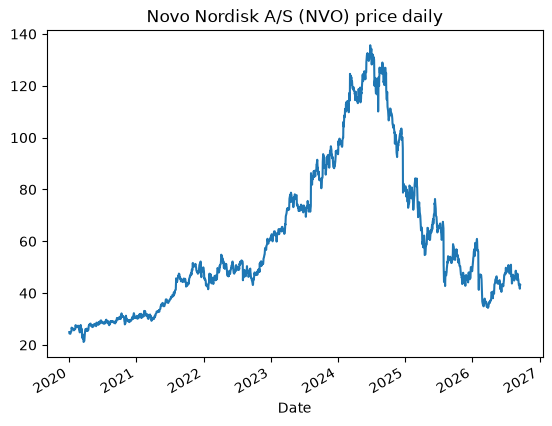

In [104]:
df_nvo_filtered_from_2020 = df_nvo[df_nvo.index >= '2020-01-01']

df_nvo_filtered_from_2020['Close'].plot.line(title='Novo Nordisk A/S (NVO) price daily')

- **Extração de ano, mês e dia da semana**

O acessador `dt` aqui é dispensado, já está embutido nos índices!

In [105]:
df_nvo.index

DatetimeIndex(['1981-04-30 00:00:00-04:00', '1981-05-01 00:00:00-04:00',
               '1981-05-04 00:00:00-04:00', '1981-05-05 00:00:00-04:00',
               '1981-05-06 00:00:00-04:00', '1981-05-07 00:00:00-04:00',
               '1981-05-08 00:00:00-04:00', '1981-05-11 00:00:00-04:00',
               '1981-05-12 00:00:00-04:00', '1981-05-13 00:00:00-04:00',
               ...
               '2026-09-04 00:00:00-04:00', '2026-09-08 00:00:00-04:00',
               '2026-09-09 00:00:00-04:00', '2026-09-10 00:00:00-04:00',
               '2026-09-11 00:00:00-04:00', '2026-09-14 00:00:00-04:00',
               '2026-09-15 00:00:00-04:00', '2026-09-16 00:00:00-04:00',
               '2026-09-17 00:00:00-04:00', '2026-09-18 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=11439, freq=None)

In [106]:
df_nvo["Ticker"] = 'NVO'
df_nvo["Year"] = df_nvo.index.year
df_nvo["Month"] = df_nvo.index.month
df_nvo["Weekday"] = df_nvo.index.weekday
df_nvo["Date"] = df_nvo.index.date

In [107]:
df_nvo.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,Weekday,Date
Date,,,,,,,,,,,,
1981-04-30 00:00:00-04:00,0.082270,0.082913,0.082270,0.082270,16760000,0.0,0.0,NVO,1981,4,3,1981-04-30
1981-05-01 00:00:00-04:00,0.084520,0.086126,0.084520,0.084520,15180000,0.0,0.0,NVO,1981,5,4,1981-05-01
1981-05-04 00:00:00-04:00,0.083556,0.083556,0.082913,0.082913,3340000,0.0,0.0,NVO,1981,5,0,1981-05-04
1981-05-05 00:00:00-04:00,0.082913,0.083234,0.082270,0.082270,12560000,0.0,0.0,NVO,1981,5,1,1981-05-05
1981-05-06 00:00:00-04:00,0.084198,0.085484,0.084198,0.084198,15700000,0.0,0.0,NVO,1981,5,2,1981-05-06


- **Deslocamento temporal: `.shift()`**

In [108]:
df_nvo[["Close"]].head()

,Close
Date,
1981-04-30 00:00:00-04:00,0.082270
1981-05-01 00:00:00-04:00,0.084520
1981-05-04 00:00:00-04:00,0.082913
1981-05-05 00:00:00-04:00,0.082270
1981-05-06 00:00:00-04:00,0.084198


> A partir de uma data de referência, qual o preço de fechamento de amanhã? $\uparrow$

> Acessa uma observação futura à data atual

In [109]:
df_nvo[["Close"]].shift(-1).head()

,Close
Date,
1981-04-30 00:00:00-04:00,0.084520
1981-05-01 00:00:00-04:00,0.082913
1981-05-04 00:00:00-04:00,0.082270
1981-05-05 00:00:00-04:00,0.084198
1981-05-06 00:00:00-04:00,0.084841


> A partir de uma data de referência, qual o preço de fechamento de ontem? $\downarrow$

> Acesso uma observação passada à data atual

In [110]:
df_nvo[["Close"]].shift(+1).head()

,Close
Date,
1981-04-30 00:00:00-04:00,NaN
1981-05-01 00:00:00-04:00,0.082270
1981-05-04 00:00:00-04:00,0.084520
1981-05-05 00:00:00-04:00,0.082913
1981-05-06 00:00:00-04:00,0.082270


In [111]:
df_nvo["previous_close_1d"] = df_nvo["Close"].shift(+1)
df_nvo["future_close_1d"] = df_nvo["Close"].shift(-1)

In [112]:
df_nvo["previous_close_30d"] = df_nvo["Close"].shift(+30)
df_nvo["future_close_30d"] = df_nvo["Close"].shift(-30)

- **Crescimentos passado e futuro**

In [113]:
df_nvo["growth_1d"] = df_nvo["Close"] / df_nvo["previous_close_1d"]
df_nvo["growth_30d"] = df_nvo["Close"] / df_nvo["previous_close_30d"]

> Para modelos de Regressão

In [116]:
df_nvo["growth_future_1d"] = df_nvo["future_close_1d"] / df_nvo["Close"]
df_nvo["growth_future_30d"] = df_nvo["future_close_30d"] / df_nvo["Close"]

> Para classificadores binários

In [117]:
df_nvo["is_positive_growth_1d_future"] = np.where(df_nvo["growth_future_1d"] > 1, 1, 0)
df_nvo["is_positive_growth_30d_future"] = np.where(df_nvo["growth_future_30d"] > 1, 1, 0)

- **Métricas básicas e visualização da taxa de crescimento $g_{t}$**

> **Taxa de crescimento**: $g_t = \dfrac{P_t}{P_{t-1}}$

> **Crescimento percentual**: outra escala para a mesma taxa, medindo o desvio em relação a $1$ (o preço de ontem), e não à média: $\%_t = (g_t - 1) \times 100$

> **Média**: como a média é linear, $\bar g = 1 + \dfrac{\bar{\%}}{100}$. Com crescimento percentual médio de $0{,}07\%$, a linha vertical fica em $\bar g \approx 1{,}0007$ (exibido como $1{,}00$).

> **Desvio padrão**: dispersão dos valores em torno da *própria média*, e não de $1$: $\sigma = \sqrt{\dfrac{1}{N-1}\sum_t (x_t - \bar x)^2}$. Aplicado a $\%_t$, é a **volatilidade** diária.


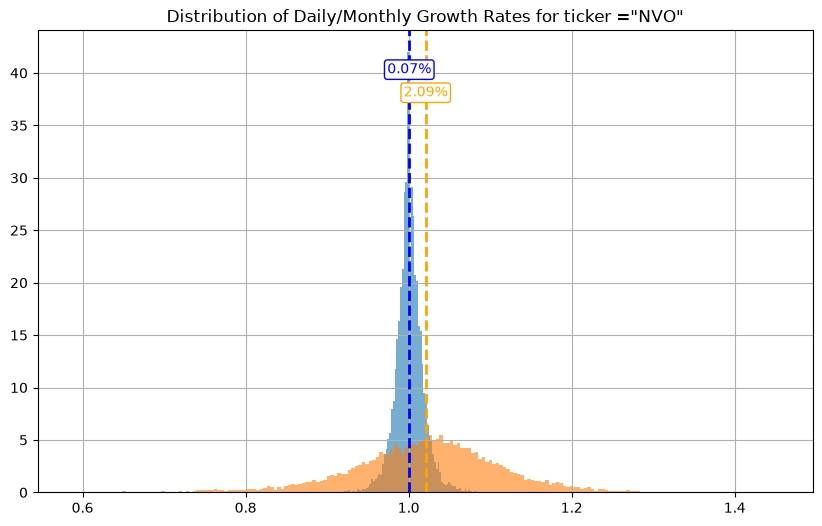

In [132]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Daily/Monthly Growth Rates for ticker ="NVO"')

df_nvo.growth_1d.hist(bins=200, alpha=0.6, density=True)
df_nvo.growth_30d.hist(bins=200, alpha=0.6, density=True)

# Add vertical lines for averages
mean_1d = df_nvo.growth_1d.mean()
mean_30d = df_nvo.growth_30d.mean()

plt.axvline(mean_1d, color='blue', linestyle='--', linewidth=2, label=f'1d avg = {mean_1d:.3f}')
plt.axvline(mean_30d, color='orange', linestyle='--', linewidth=2, label=f'30d avg = {mean_30d:.3f}')

# Add mean text labels (as percent change)
ymax = plt.ylim()[1]
plt.text(mean_1d, ymax * 0.90,
         f'{(mean_1d - 1) * 100:.2f}%',
         color='blue', ha='center', va='bottom',
         bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.2'))

plt.text(mean_30d, ymax * 0.85,
         f'{(mean_30d - 1) * 100:.2f}%',
         color='orange', ha='center', va='bottom',
         bbox=dict(facecolor='white', edgecolor='orange', boxstyle='round,pad=0.2'))


plt.show()

- **Features, target e *data leakage***

Considere \(P_t\) como o preço disponível na data \(t\).

> **Feature:** informação conhecida no momento em que a previsão é realizada.

> **Target:** resultado futuro que queremos prever.

Por exemplo, se a previsão for feita após o fechamento do dia \(t\):

$$
\text{growth\_1d}(t)=\frac{P_t}{P_{t-1}},
\qquad
\text{growth\_30d}(t)=\frac{P_t}{P_{t-30}}
$$

Essas variáveis utilizam apenas preços conhecidos até \(t\) e, portanto, podem ser usadas como **features**.

Já o crescimento futuro é definido por:

$$
\text{growth\_future\_kd}(t)=\frac{P_{t+k}}{P_t}
$$

Como depende de $P_{t+k}$, que ainda não é conhecido na data \(t\), essa variável deve ser usada como **target**, não como feature. Sua versão binária indica a direção do movimento:

$$
\text{is\_positive\_growth\_future}(t)=
\begin{cases}
1, & P_{t+k}>P_t\\
0, & P_{t+k}\leq P_t
\end{cases}
$$

#### O que é *data leakage*?

*Data leakage* ocorre quando o modelo recebe, direta ou indiretamente, alguma informação que não estaria disponível no momento real da previsão. Exemplos:

* usar `growth_future_*` como feature;
* calcular uma feature com valores posteriores à data \(t\);
* ajustar normalizações ou transformações usando todo o período antes da separação;
* misturar observações futuras e passadas por meio de uma divisão aleatória de séries temporais.

Por isso, dados de mercado normalmente devem ser separados temporalmente:

$$
\text{treino} \rightarrow \text{validação} \rightarrow \text{teste}
$$

#### Targets ainda desconhecidos

Nas últimas $k$ observações da série, $P_{t+k}$ ainda não existe. Portanto, o target dessas linhas é **desconhecido**, não negativo.

Uma comparação direta como:

```python
df["future_growth_kd"] > 1
```

transforma `NaN > 1` em `False`, podendo atribuir incorretamente o rótulo `0`. O correto é preservar esses valores como ausentes e removê-los apenas quando for necessário treinar ou avaliar o modelo.

```python
df["target"] = (
    (df["future_growth_kd"] > 1)
    .where(df["future_growth_kd"].notna())
    .astype("Int64")
)
```

> **Regra prática:** uma feature deve conter somente informações disponíveis até o instante da previsão; o target descreve o que acontece depois dele.
